<a href="https://colab.research.google.com/github/rishi0-405/CodeAlpha_Netflix_EDA/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

df = pd.read_csv("/archive (1).zip")

#View DATA Set

df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


Missing values

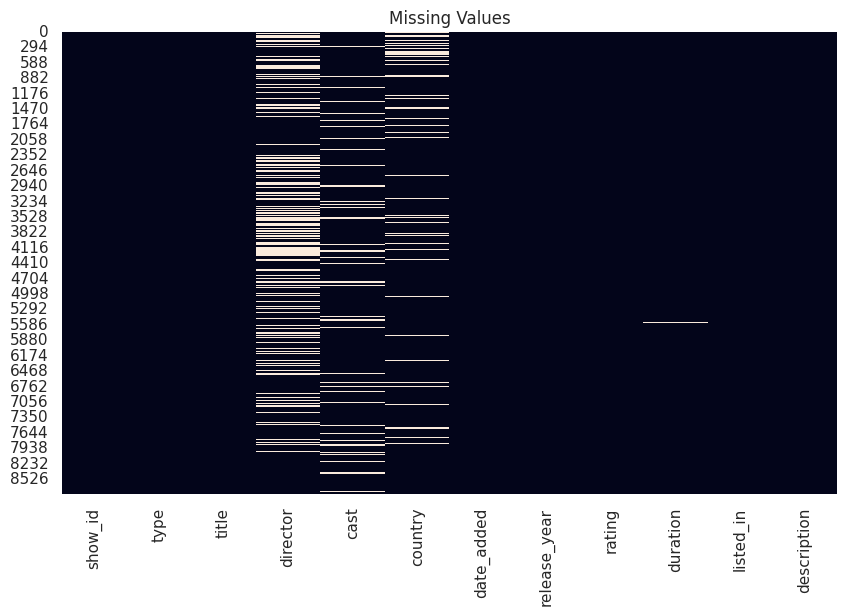

In [5]:
df.isnull().sum()

#Visualize missing values

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

Remove Duplicates

In [10]:
print("Duplicates :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

#Convert Dates

df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

Duplicates : 0


Vizualization 1

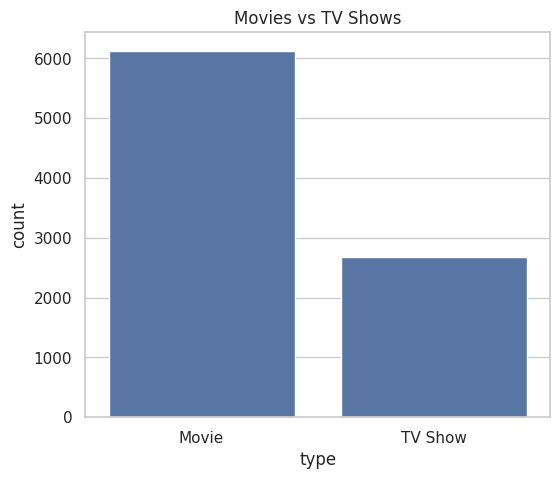

In [11]:
#Movies vs TV Shows

plt.figure(figsize=(6,5))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows")
plt.show()

Vizualization 2

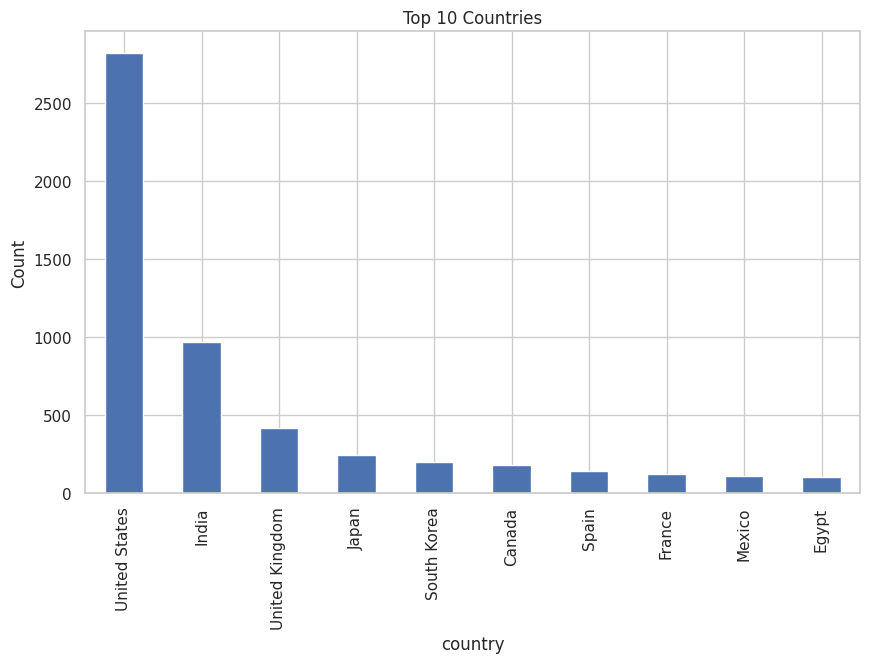

In [12]:
#Top 10 Countries

plt.figure(figsize=(10,6))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.ylabel("Count")
plt.show()

Vizualization 3

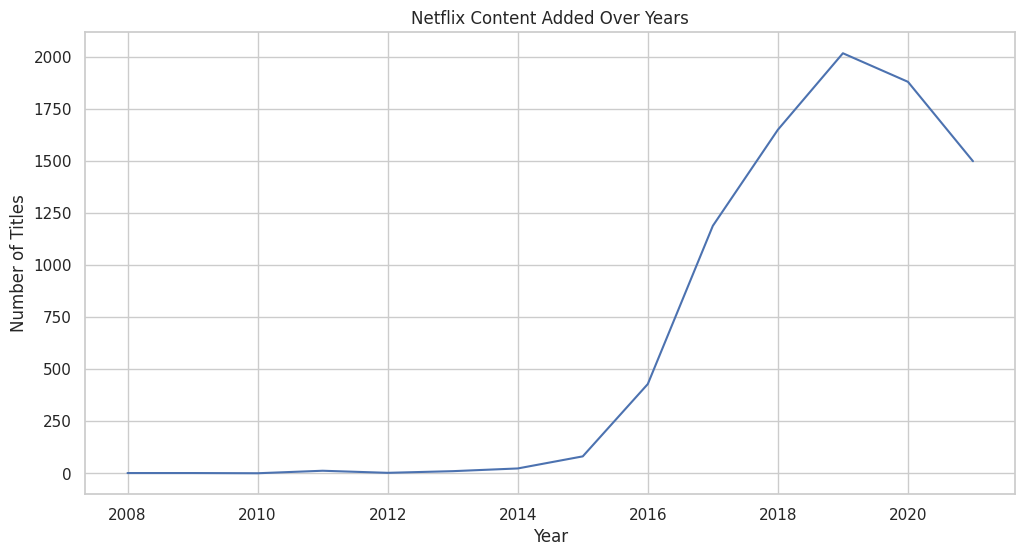

In [13]:
#Content Added Over Years

df['year_added'] = df['date_added'].dt.year
plt.figure(figsize=(12,6))
df['year_added'].value_counts().sort_index().plot()
plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Vizualization 4

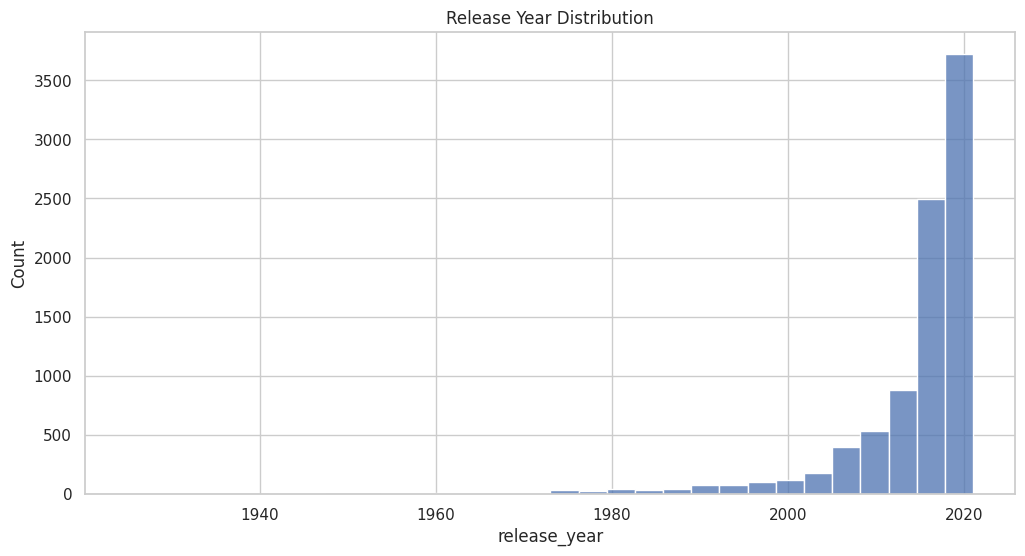

In [14]:
#Release Year Distribution

plt.figure(figsize=(12,6))
sns.histplot(df['release_year'], bins=30)
plt.title("Release Year Distribution")
plt.show()

Vizualization 5

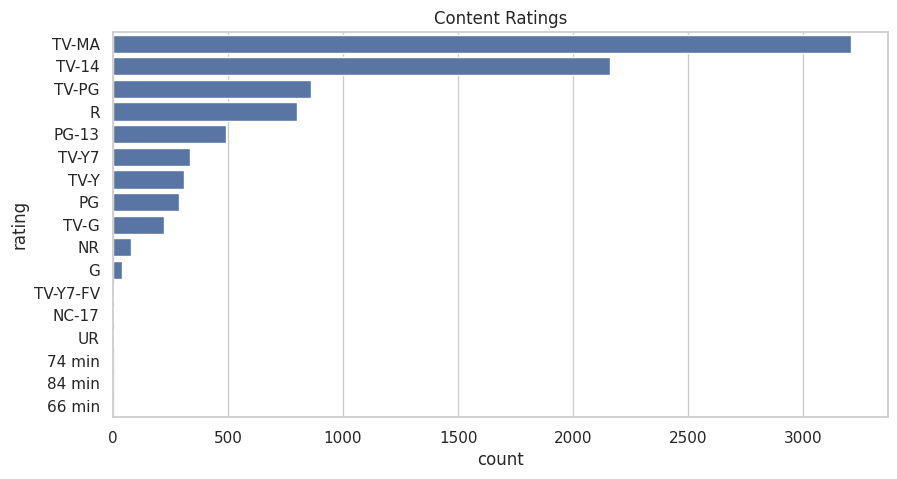

In [15]:
#Most Common Ratings

plt.figure(figsize=(10,5))
sns.countplot(
    y=df['rating'],
    order=df['rating'].value_counts().index
)
plt.title("Content Ratings")
plt.show()

vizualization 6

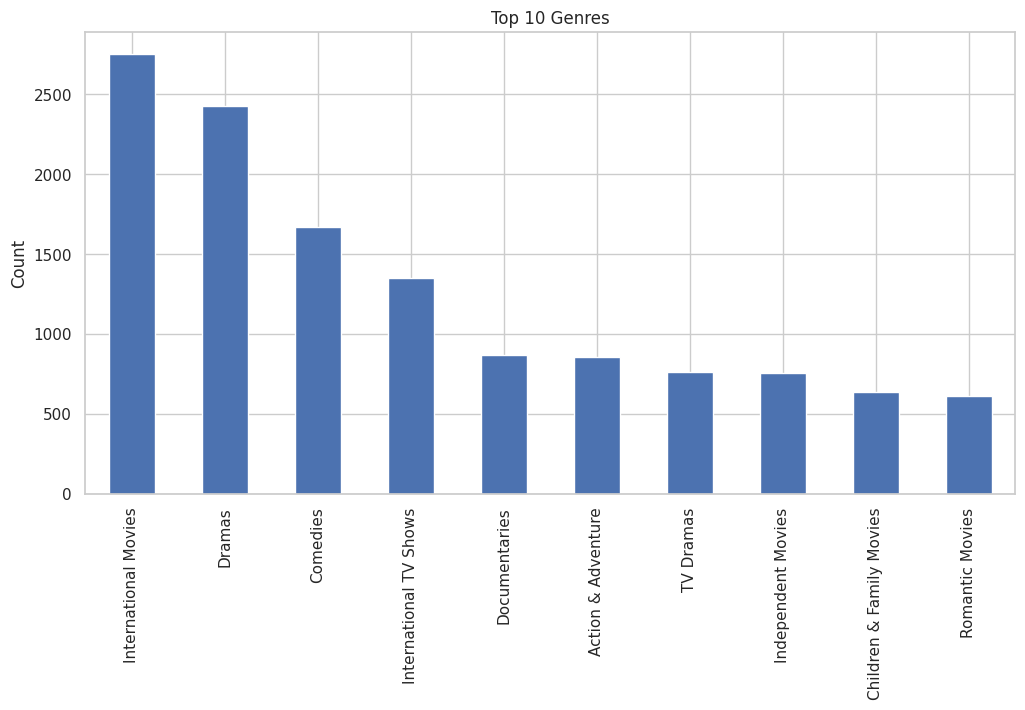

In [16]:
#Top Genres

genres = df['listed_in'].str.split(', ', expand=True).stack()
plt.figure(figsize=(12,6))
genres.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.ylabel("Count")
plt.show()

vizualization 7

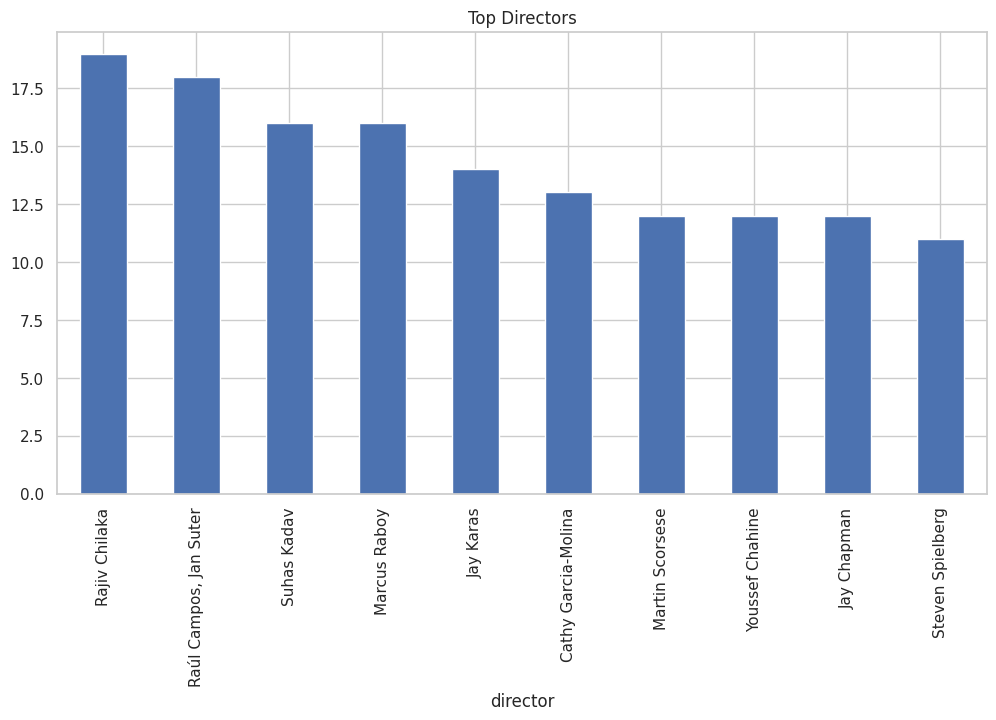

In [17]:
#Top Directors

directors = df['director'].dropna()
plt.figure(figsize=(12,6))
directors.value_counts().head(10).plot(kind='bar')
plt.title("Top Directors")
plt.show()

Vizualization 8

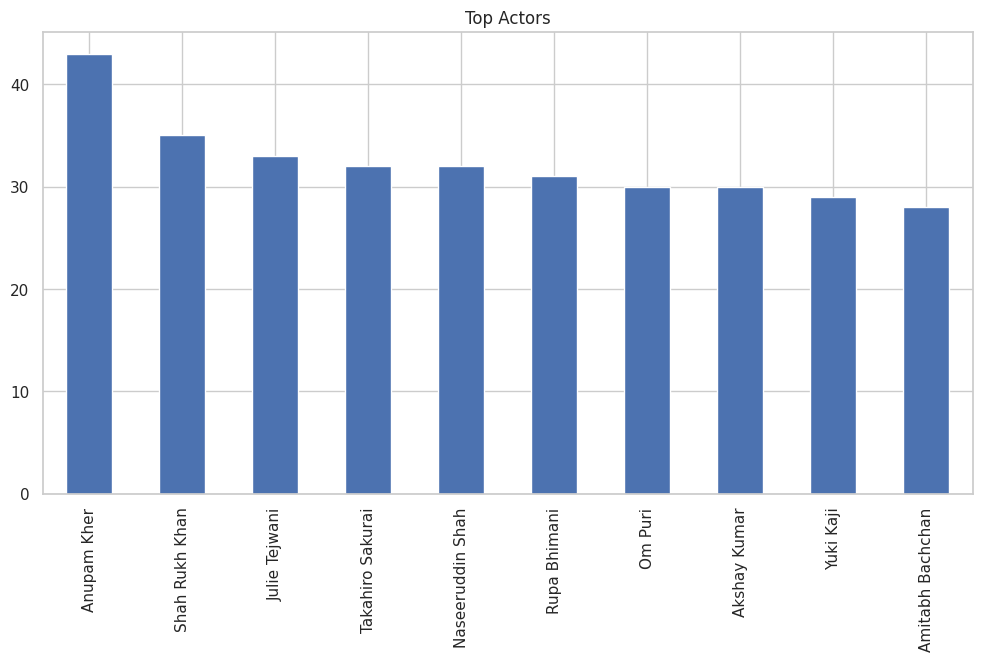

In [19]:
#Top Actors

actors = df['cast'].dropna().str.split(', ', expand=True).stack()
plt.figure(figsize=(12,6))
actors.value_counts().head(10).plot(kind='bar')
plt.title("Top Actors")
plt.show()

Vizualization 9

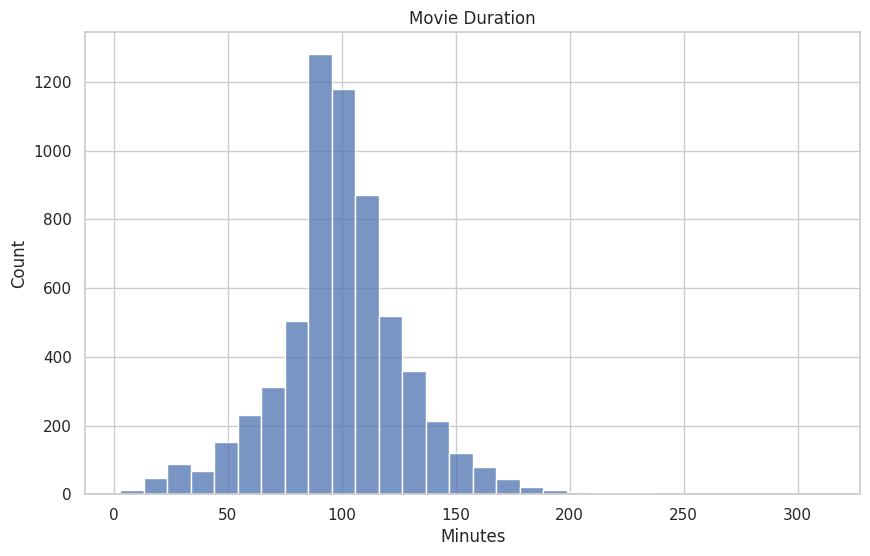

In [20]:
#movie Duration

movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].str.replace(" min","")
movies['duration'] = pd.to_numeric(
    movies['duration'],
    errors='coerce'
)
plt.figure(figsize=(10,6))
sns.histplot(movies['duration'], bins=30)
plt.title("Movie Duration")
plt.xlabel("Minutes")
plt.show()

Vizualization 10

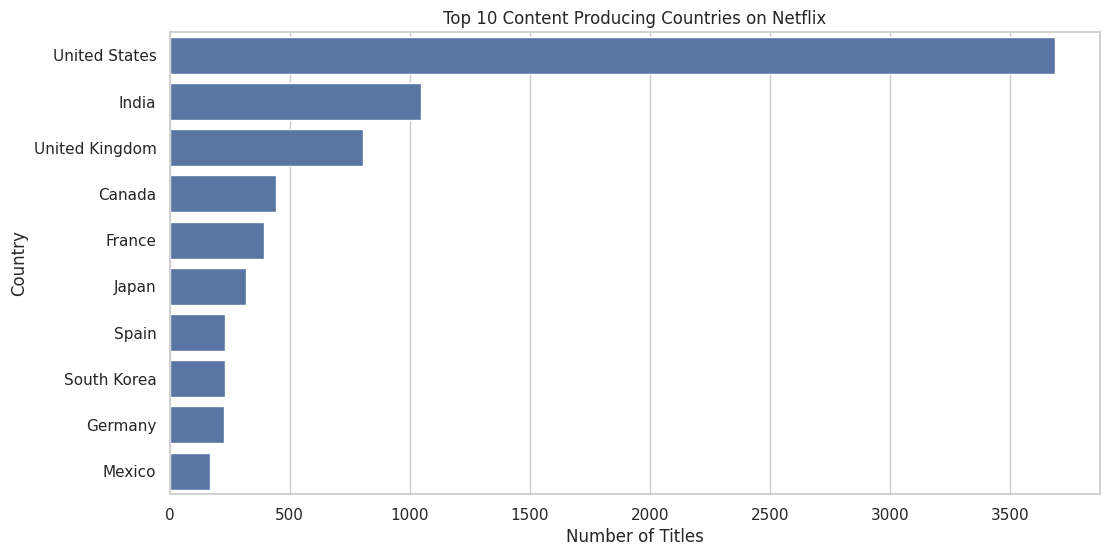

In [24]:
# Top 10 Content-Producing Countries


country_data = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
)
top_countries = country_data.value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)
plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

Vizualization 11

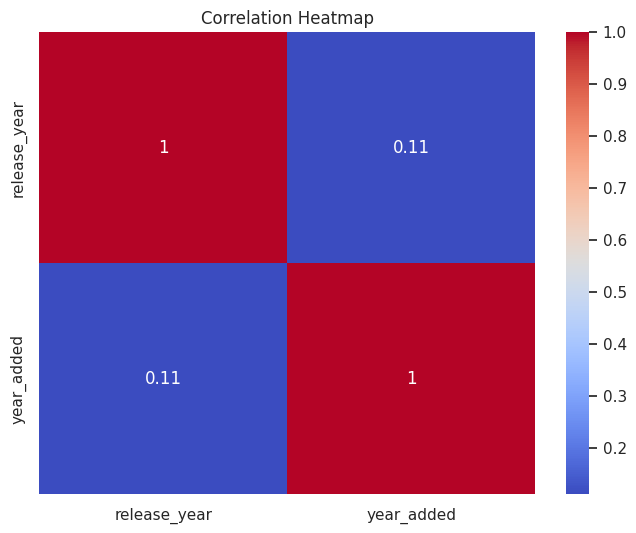

In [22]:
#Correlation Heatmap

numeric = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Vizualization 12

In [23]:
#Insights

print("Total Titles :", len(df))
print("Movies :", len(df[df['type']=="Movie"]))
print("TV Shows :", len(df[df['type']=="TV Show"]))
print("\nTop Country")
print(df['country'].value_counts().head())
print("\nTop Rating")
print(df['rating'].value_counts().head())
print("\nTop Genre")
print(genres.value_counts().head())

Total Titles : 8807
Movies : 6131
TV Shows : 2676

Top Country
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64

Top Rating
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

Top Genre
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64


conclusion

In [26]:
print("""
==========================
PROJECT CONCLUSION
==========================

This exploratory data analysis of the Netflix Movies and TV Shows dataset
provided valuable insights into Netflix's global content library.

Key Findings:

• The dataset contains both Movies and TV Shows, with Movies making up the
  majority of the available content.

• The United States is the largest contributor to Netflix's catalog,
  followed by countries such as India and the United Kingdom.

• Drama, International Movies, and Comedy are among the most popular genres,
  showing Netflix's focus on diverse entertainment.

• The number of titles added to Netflix increased rapidly after 2015,
  indicating significant platform growth during recent years.

• TV-MA is the most frequently assigned content rating, suggesting that
  a large portion of Netflix's content is targeted toward mature audiences.

• Most movies have durations between 80 and 120 minutes, which represents
  the standard movie length.

• Several directors and actors appear repeatedly in the dataset, highlighting
  long-term collaborations with Netflix.

• The analysis also showed that the dataset contains very few data quality
  issues, making it suitable for further machine learning or business analysis.

Overall Conclusion:

This project demonstrates how Exploratory Data Analysis (EDA) can transform
raw data into meaningful business insights using Python, Pandas, Matplotlib,
and Seaborn. The findings help understand Netflix's content strategy,
global expansion, genre preferences, and audience targeting.


""")


PROJECT CONCLUSION

This exploratory data analysis of the Netflix Movies and TV Shows dataset
provided valuable insights into Netflix's global content library.

Key Findings:

• The dataset contains both Movies and TV Shows, with Movies making up the
  majority of the available content.

• The United States is the largest contributor to Netflix's catalog,
  followed by countries such as India and the United Kingdom.

• Drama, International Movies, and Comedy are among the most popular genres,
  showing Netflix's focus on diverse entertainment.

• The number of titles added to Netflix increased rapidly after 2015,
  indicating significant platform growth during recent years.

• TV-MA is the most frequently assigned content rating, suggesting that
  a large portion of Netflix's content is targeted toward mature audiences.

• Most movies have durations between 80 and 120 minutes, which represents
  the standard movie length.

• Several directors and actors appear repeatedly in the datase

Future Scope

In [27]:
print("""

• Build a Netflix recommendation system.
• Predict movie ratings using machine learning.
• Perform sentiment analysis on user reviews.
• Create an interactive dashboard using Power BI or Tableau.
• Analyze trends with newly released Netflix data.
""")



• Build a Netflix recommendation system.
• Predict movie ratings using machine learning.
• Perform sentiment analysis on user reviews.
• Create an interactive dashboard using Power BI or Tableau.
• Analyze trends with newly released Netflix data.

